### 📝 Corrected Notes: PySpark Pipelining & Shuffling

**Pipelining & Narrow Transformations:**
Spark uses "pipelining" to optimize execution. It combines multiple *narrow transformations* (like `map`, `filter`, `withColumn`) into a single pipeline. Spark executes this entire pipeline continuously on a single partition of data in memory, without writing intermediate results to disk. It runs similar pipelines concurrently across all partitions of the data.

**Wide Transformations & Shuffling:**
When Spark encounters a *wide transformation* (like `groupBy`, `join`, `orderBy`), it requires data from multiple partitions to be grouped together. This data exchange across the network is called a **Shuffle**.

**Stages:**
A shuffle breaks the pipeline. Spark divides the job into multiple **Stages** at every shuffle boundary:
1. **Stage 1 (Map Stage):** Spark executes all narrow transformations up to the shuffle. At the end of this stage, it writes the data into **Shuffle Files** on the local disk of the executors. (These files are encoded in Tungsten binary format, also known as Unsafe Row format, for extreme efficiency).
2. **Stage 2 (Reduce Stage):** Spark reads these temporary shuffle files across the network, groups the data, and continues processing the remaining narrow transformations.

**Why avoid shuffles?**
Writing shuffle files to disk (Disk I/O) and transferring them across executors (Network I/O) are very expensive operations. This is why it is highly recommended to avoid shuffles whenever possible. When shuffles are unavoidable, we must optimize them (e.g., by tuning shuffle partitions or using broadcast joins).

---

### 🧠 Explanations of Key Concepts

#### 1. What is a "Partition"?
A **partition** is a smaller, logical chunk of your large dataset. 
Instead of processing a massive 100GB file all at once, Spark splits it into, say, 1,000 partitions of 100MB each. These partitions are distributed across the different worker nodes in your cluster so they can be processed in parallel. 

#### 2. What is a "Task"?
A **task** is the absolute smallest unit of work in Spark. 
A task is basically Spark sending your code (the pipeline) to an executor to be run on **exactly one partition** of data. 
*Rule of thumb:* `1 Task = 1 Partition`. If your data is split into 200 partitions, Spark will launch 200 tasks to process that stage.

#### 3. Why is he saying "40" (Cores)?
You likely noticed **"40 Cores Total"** in the Spark Master UI screenshot you shared earlier. 
Here is what that means:
* You have **2 Spark Worker** containers running.
* By default, a Spark Worker container will grab all the available CPU cores on the host machine it's running on unless constrained. 
* In this case, each worker container has detected **20 CPU Cores**, giving a total of **40 Cores** available in your cluster (`20 + 20 = 40`). 
* *Note:* Even though the cluster has 40 cores available, your Python code explicitly told Spark to only use a maximum of 16 cores for this specific app (`.config("spark.cores.max", 16)`).

In [4]:
from pyspark.sql import SparkSession
spark = (
    SparkSession.builder.appName("Optimizing Shuffles")
    .master("spark://4619b568af8b:7077")
    .config("spark.cores.max",16)
    .config("spark.executor.cores",4)
    .config("spark.executor.memory","512M")
    .getOrCreate()
)

spark

In [5]:
spark.sparkContext.defaultParallelism

16

In [6]:
# Disable AQE and Broadcast join

spark.conf.set("spark.sql.adaptive.enabled", False)
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", False)
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)


In [7]:
_schema = "first_name string, last_name string, job_title string, dob string, email string, phone string, salary double, department_id int"
emp = spark.read.format("csv").schema(_schema).option("header", True).load("/data/csv/employee_records.csv")

In [8]:
# finding out avg salary as per dept
from pyspark.sql.functions import avg
emp_avg = emp.groupBy("department_id").agg(avg("salary").alias("avg_sal"))

In [9]:
# write emp_avg to simulate it for performance benchmarking
emp_avg.write.format("noop").mode("overwrite").save()

If we check the Spark UI at http://localhost:4040/jobs/:
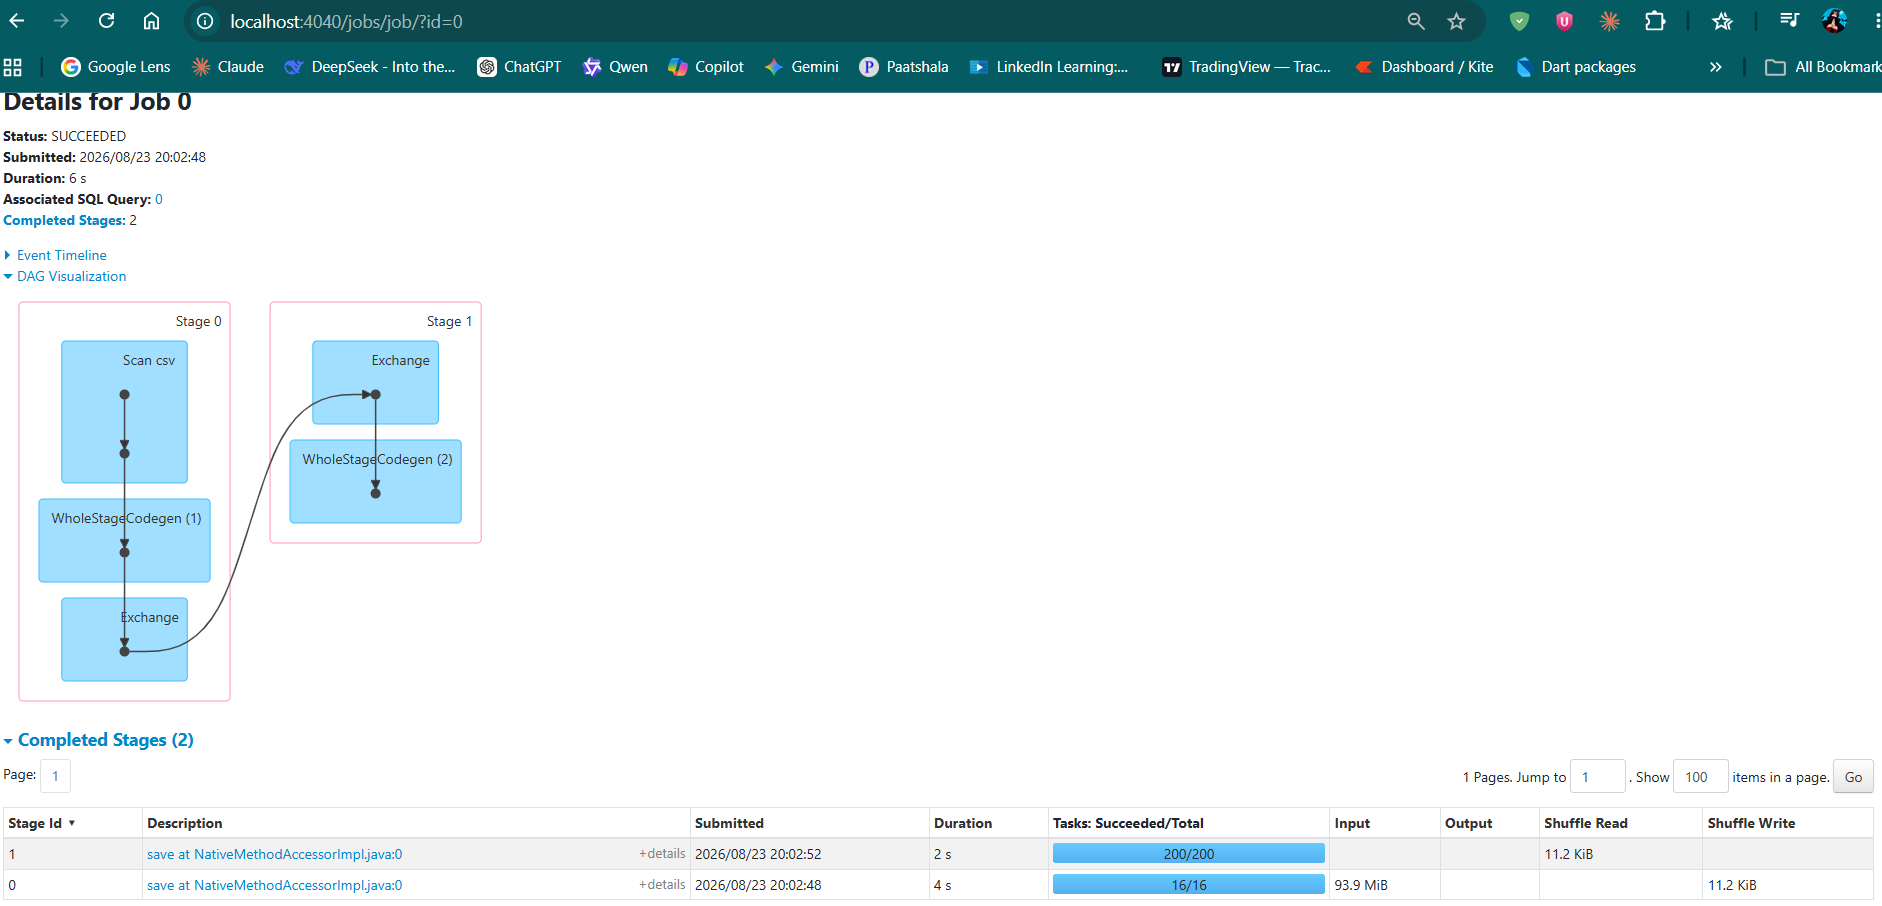
We can see an Exchange here, which is caused by the `groupBy` (a wide transformation).
- **Stage 1 (Map):** Used 16 tasks to read 93.9 MiB of input data and wrote 11.2 KiB of shuffle data.


In [10]:
# Check Default Spark Shuffle Partition setting
spark.conf.get("spark.sql.shuffle.partitions")

'200'

Expanding the first stage to understand it better:
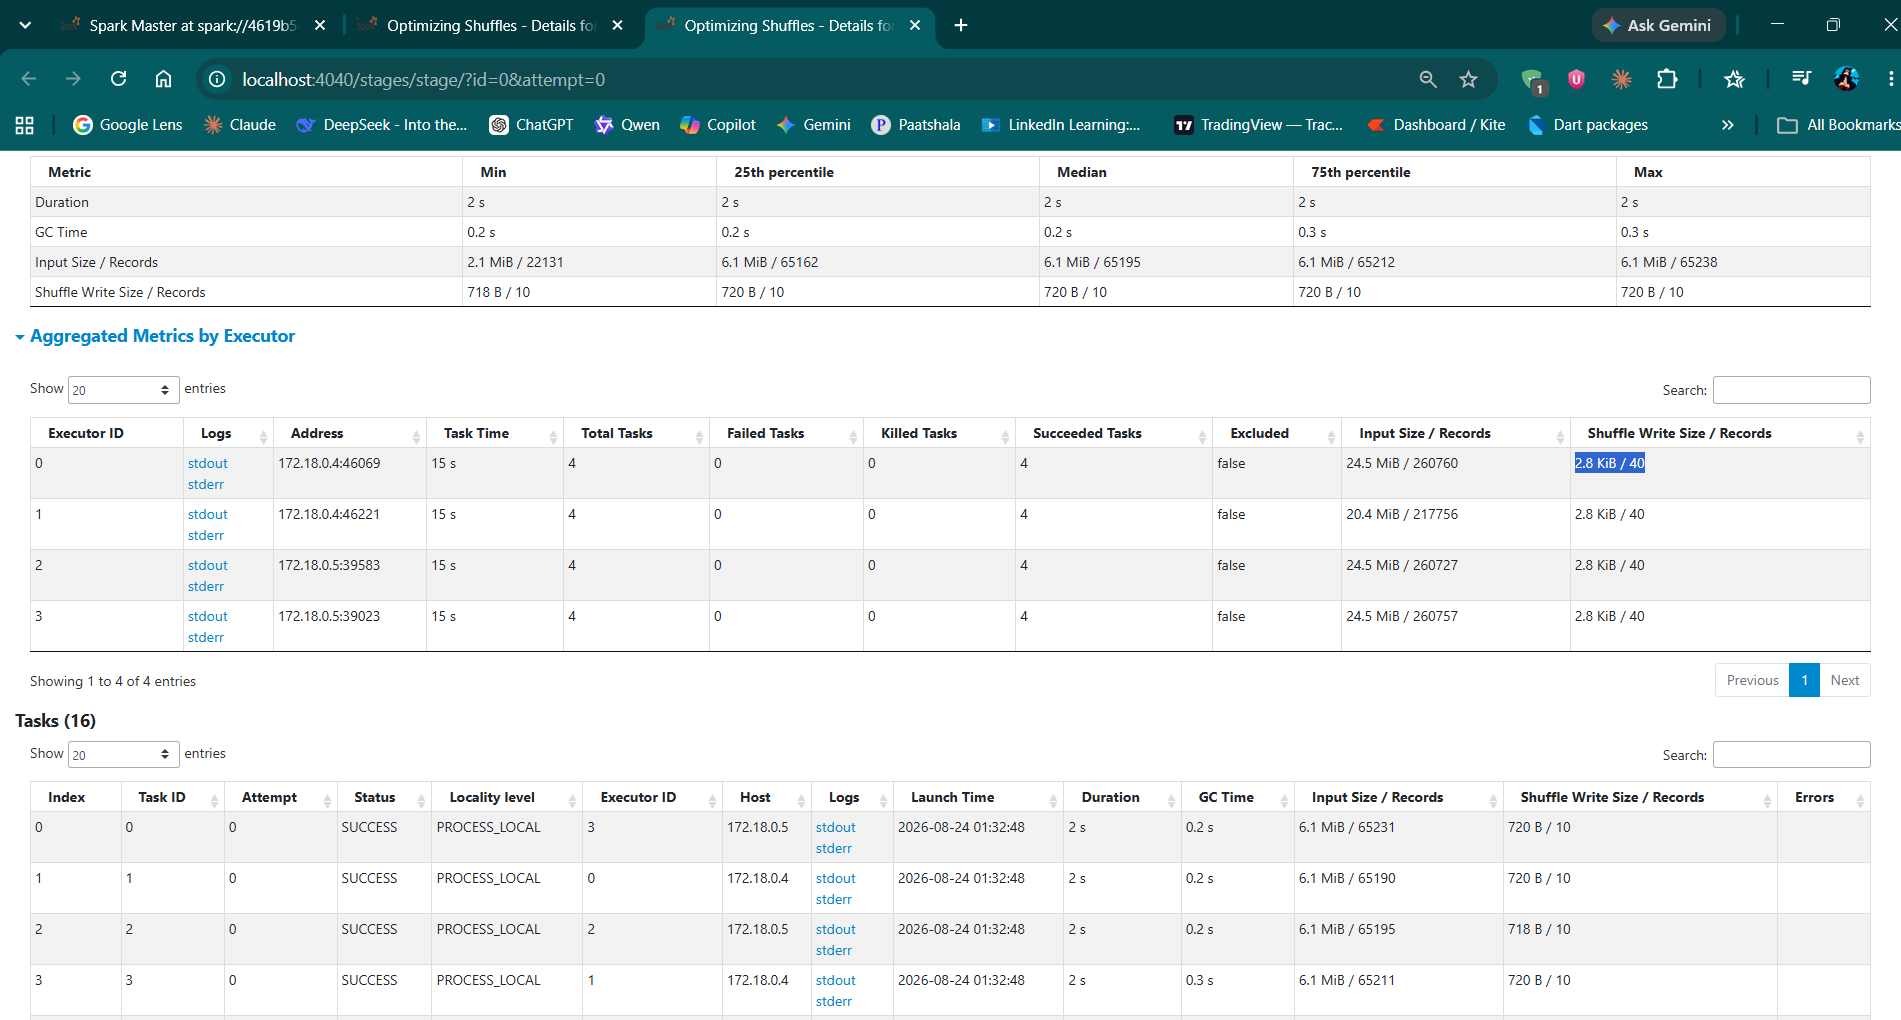


In [11]:
from pyspark.sql.functions import spark_partition_id
emp.withColumn("partition_id", spark_partition_id()).where("partition_id = 0").show()

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+------------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|partition_id|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+------------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8|           0|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7|           0|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873.820.0518x825|131900.0|           10|           0|
|      John|    Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x624|485506.0|            1|           0|
|  Michelle|   Elliott|      Air cabin crew|1975-03-31|tiffany

As seen above, multiple `department_id`s can reside in the same partition.
**Why 40 records?** 
Each partition is processed by a single task. We have 10 departments in total, and 4 tasks are executing per executor. 


Now, if we look at **Stage 2**:
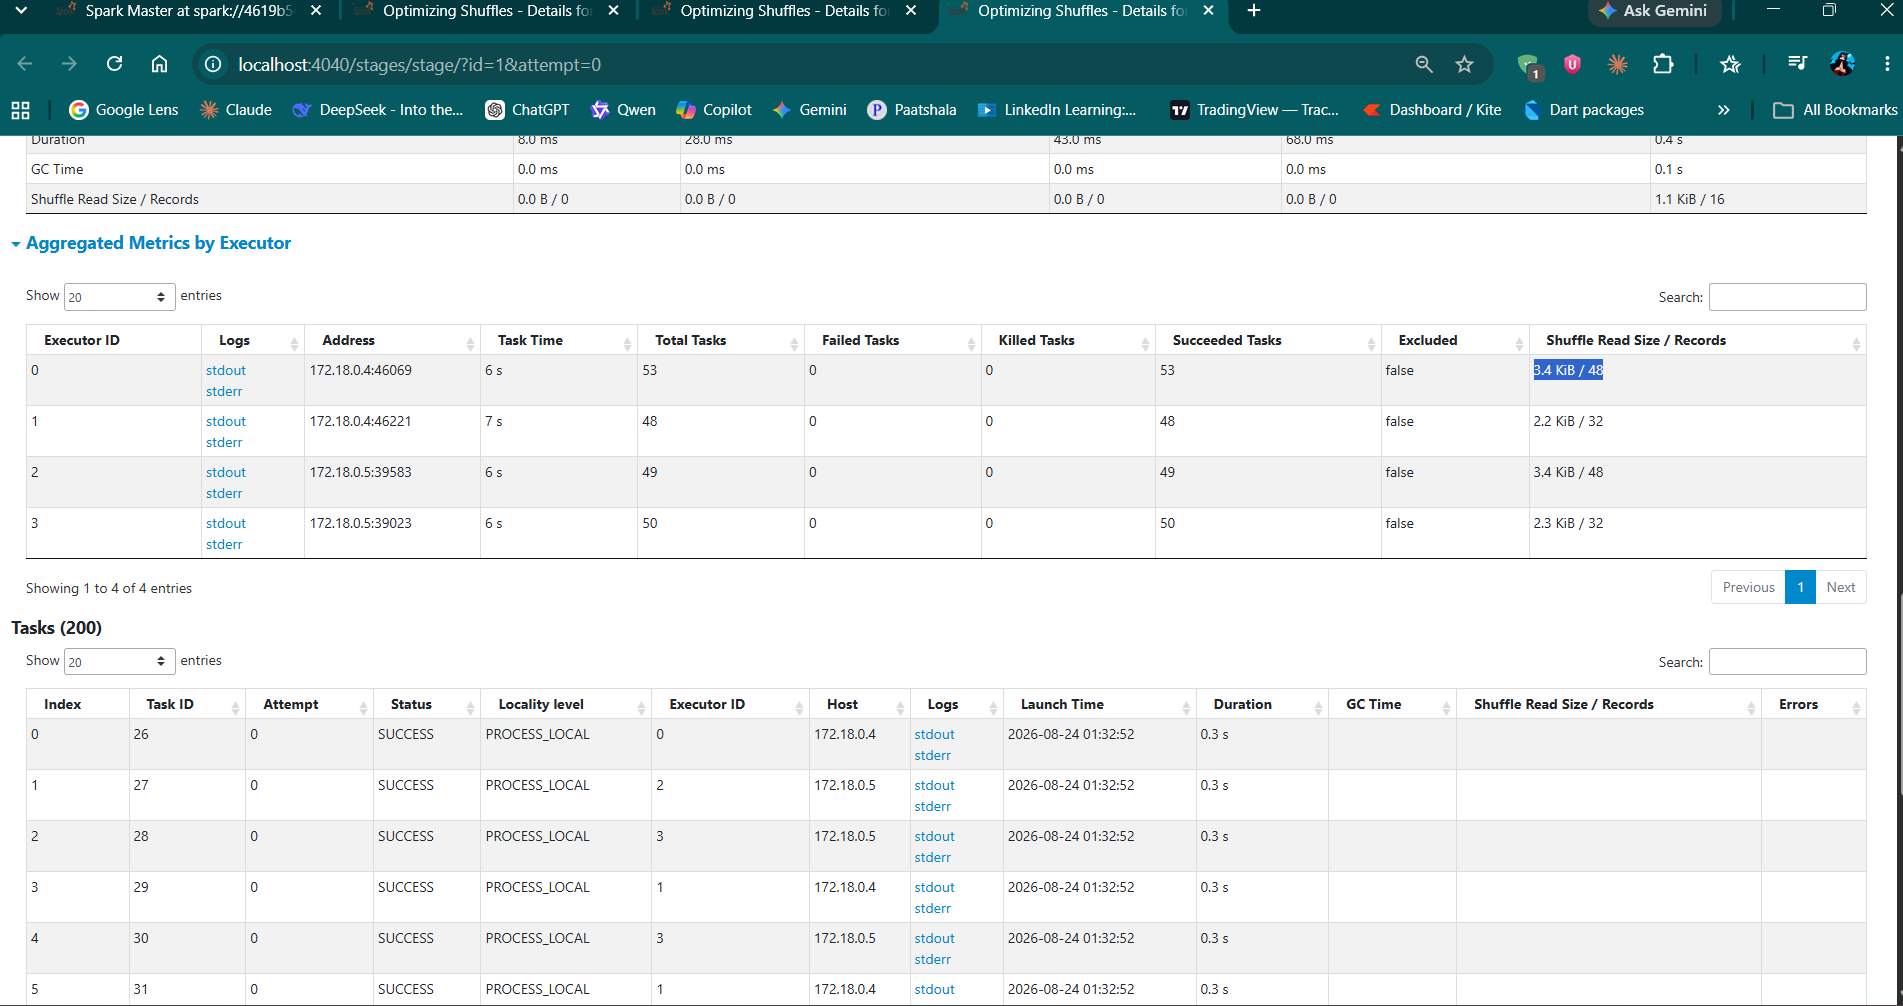
The number of records read is very small compared to the number of tasks involved (200 default tasks).
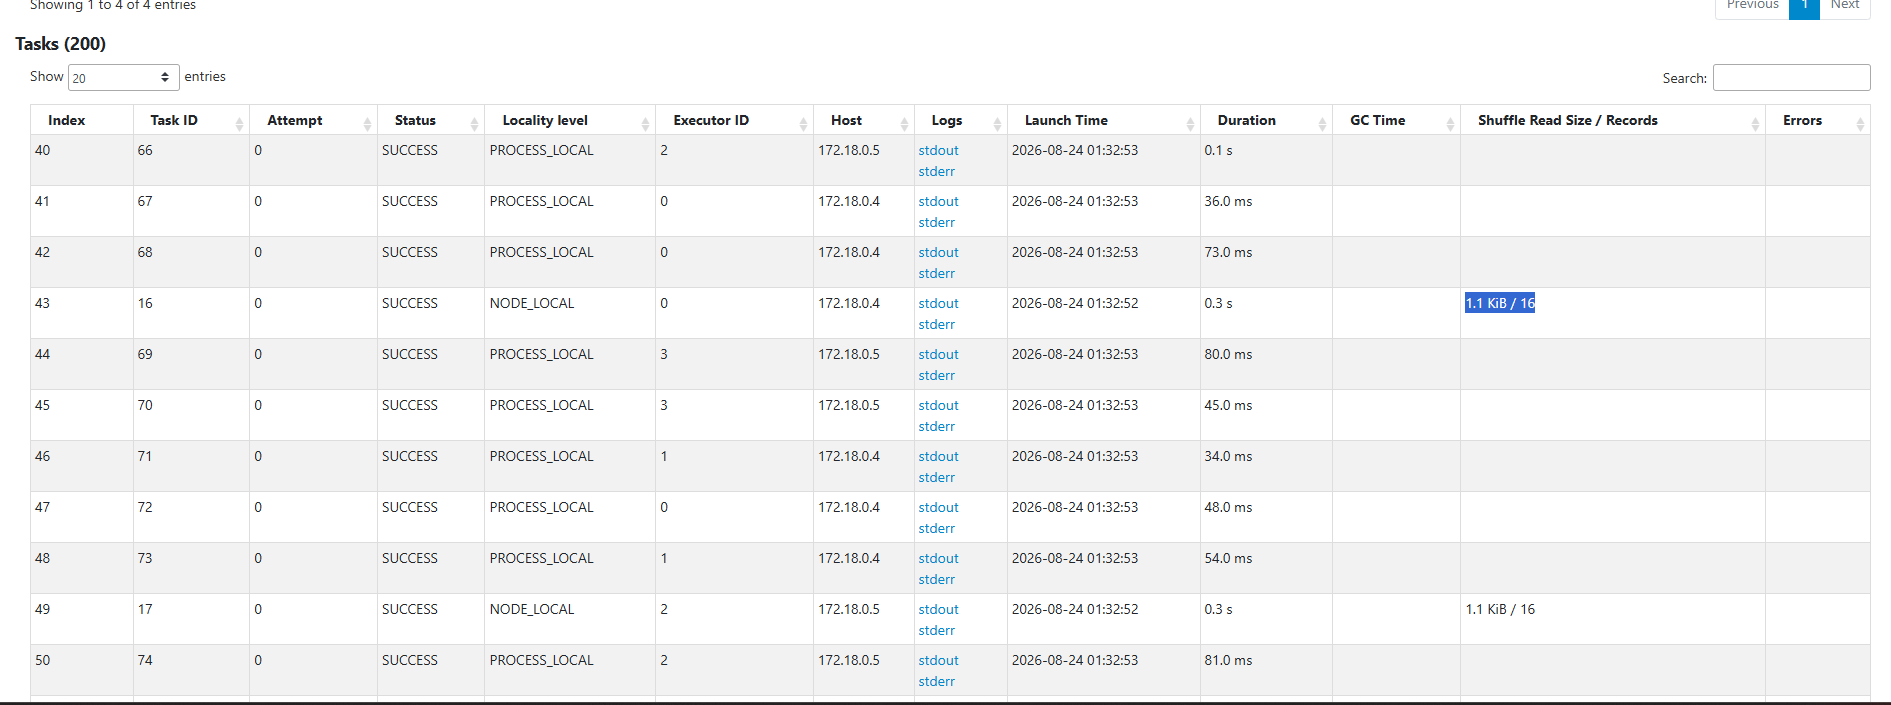


In [ ]:
# we have to decide the number of shuffle task properly in order to optimize this
# it took 6sec to perform the 1st operation
spark.conf.set("spark.sql.shuffle.partitions", "100")
spark.conf.get("spark.sql.shuffle.partitions")

'100'

In [13]:
# write emp_avg to simulate it for performance benchmarking
emp_avg.write.format("noop").mode("overwrite").save()

After optimizing, it now takes only 1 second!
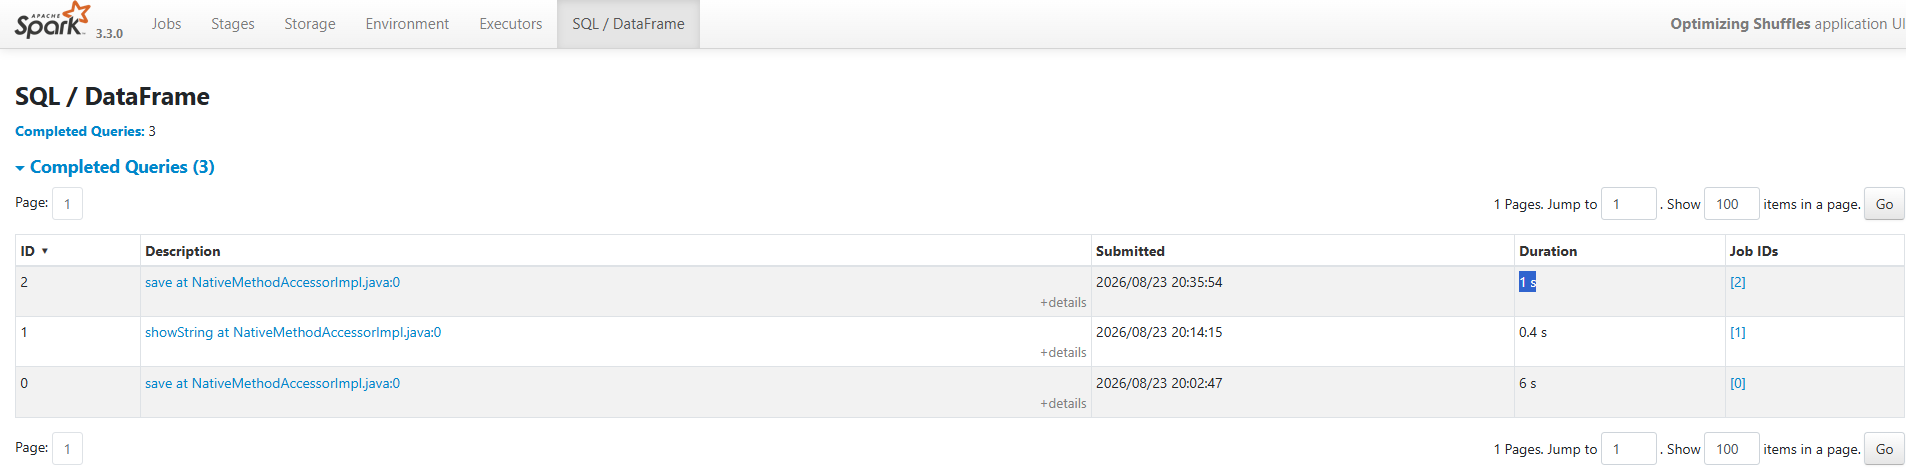
We can see it now only used 100 tasks for Job ID 2:
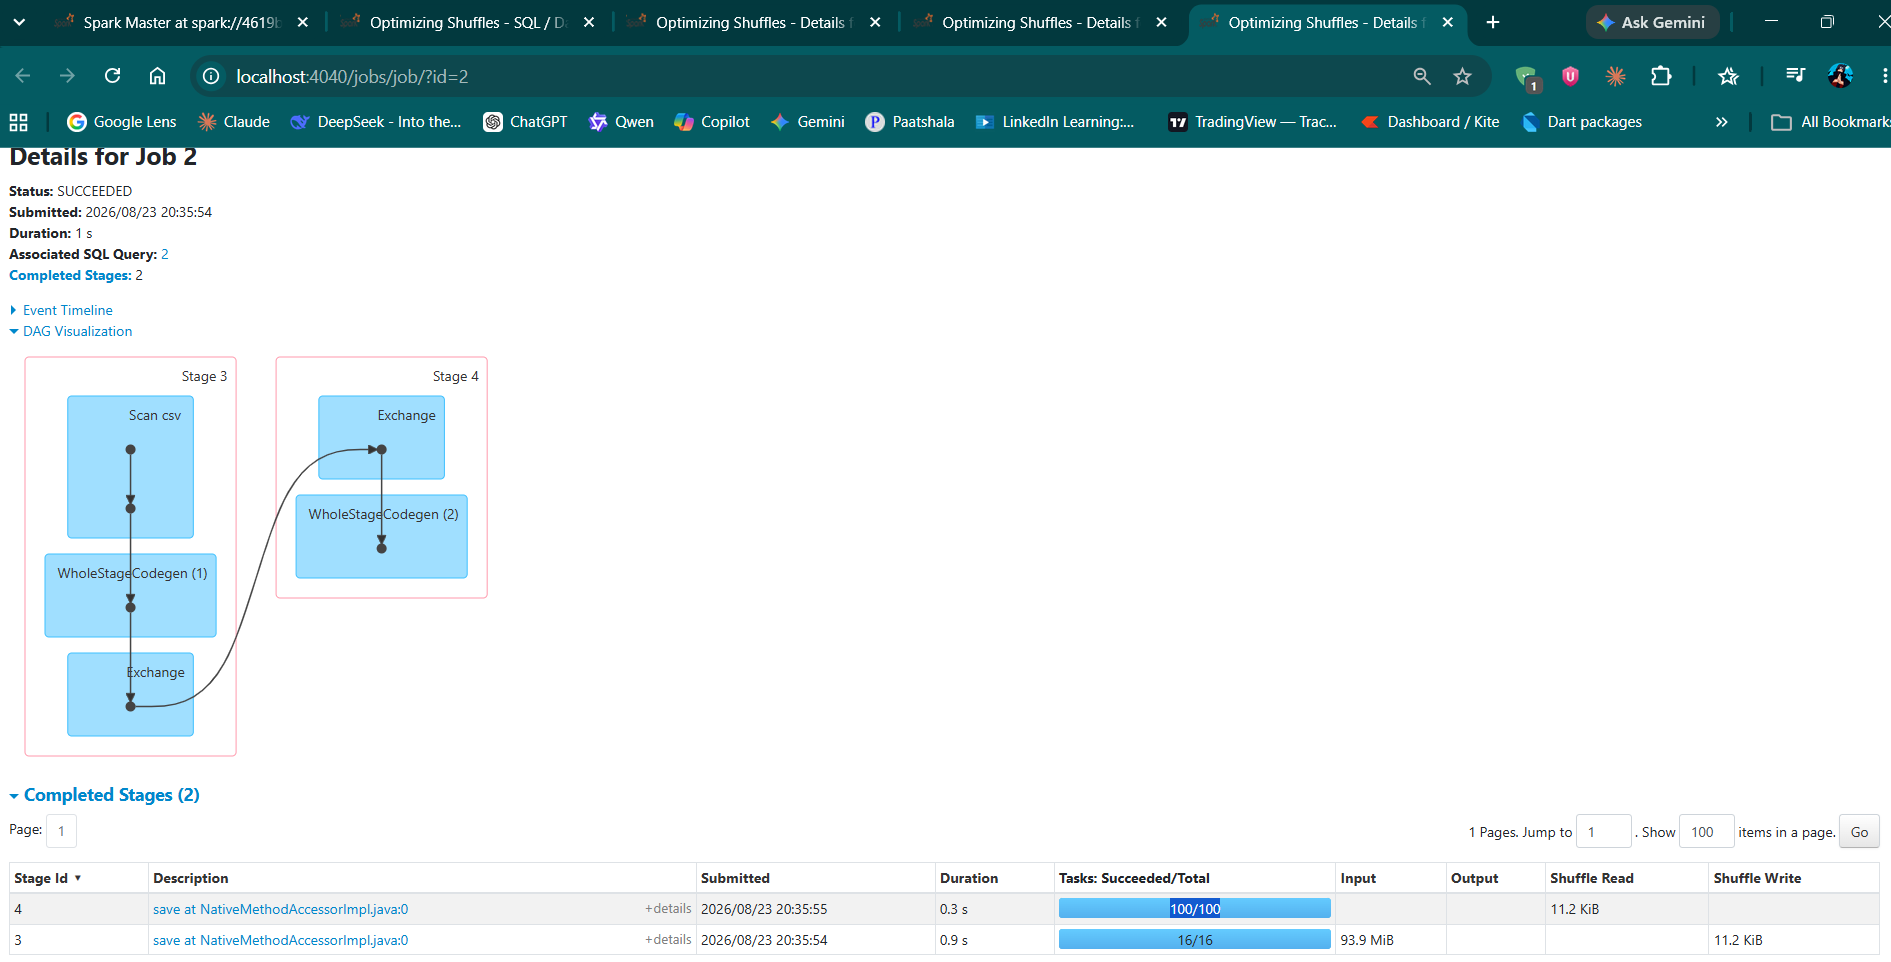

However, this is still an overkill, as only 10 tasks are actually reading data (since we only have 10 departments):
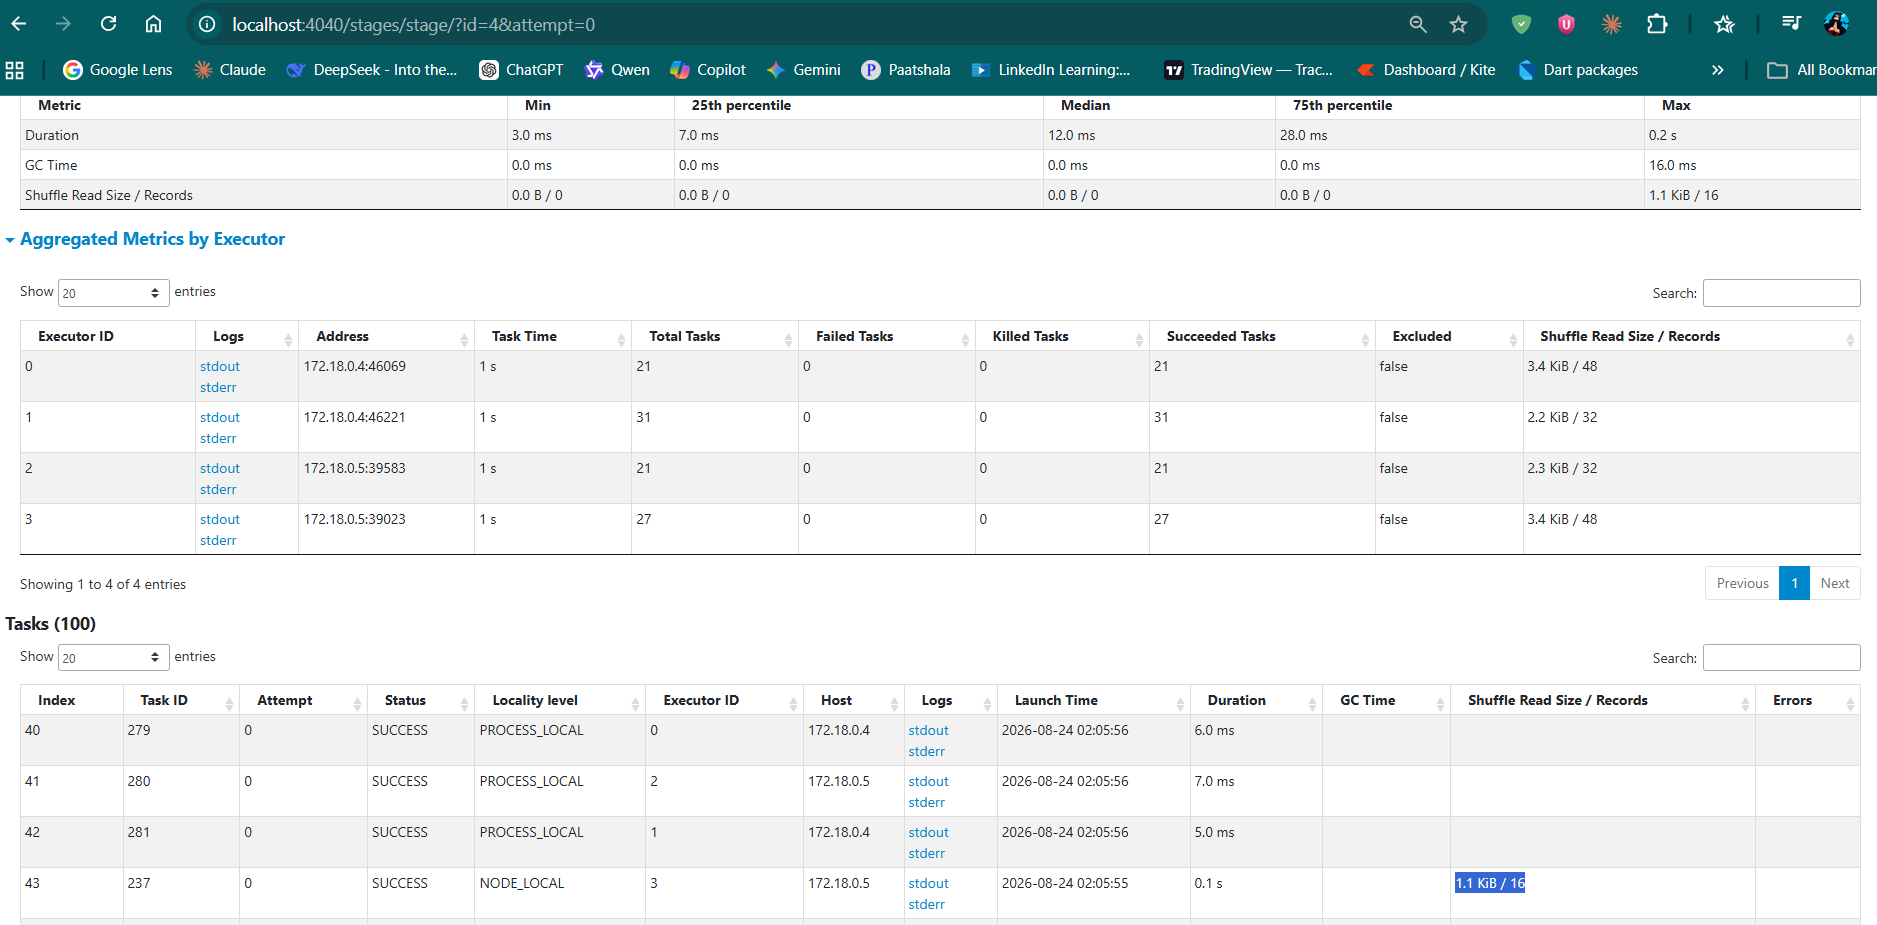


In [14]:

spark.conf.set("spark.sql.shuffle.partitions", "16")
spark.conf.get("spark.sql.shuffle.partitions")

'16'

In [15]:
# write emp_avg to simulate it for performance benchmarking
emp_avg.write.format("noop").mode("overwrite").save()

**Important Note:** 
Configuring shuffle partitions to a very low number can sometimes lead to **Out of Memory (OOM)** errors. 


In [ ]:
# also partitioned data can improve the performance

The shuffle write size is extremely small now. 
